# 03 — Robustness checks on the L1 regression headline

**What this notebook does:** runs three canonical out-of-sample robustness checks on the README's headline result (`lasso_elasso_pit_h21`, 9-feature L1 regression at 21-day target, OOS IC +0.0695 on 2025+). Each check tests one independent way the headline could be misleading.

**The three checks:**

| Check | Question it answers | Failure mode it catches |
|---|---|---|
| **1. Bootstrap CI on IC** | Is the headline IC distinguishable from a single lucky window? | A skewed IC distribution where one or two big days drag the mean above zero. |
| **2. Decile bucket monotonicity** | Is the ranking signal monotonic from low-prediction to high-prediction deciles? | A U-shape (signal only in the tails) or a flat curve (no ranking ability). |
| **3. Time-split partition** | Is the IC replicable across two non-overlapping windows? | A regime-conditional result that lives entirely in one half of the eval slice. |

All three apply the same methodology as the README's legacy v2 ablation (previously documented in notebooks 00 + earlier revisions of this notebook). The methodology is model-agnostic; pointing it at the current headline gives the L1 regression the same rigor screening.

**Headline model under test:** `lasso_elasso_pit_h21` — 9 documented academic anomalies, L1-regularized cross-sectional regression with inner-CV α selection, walk-forward refitted annually on the PIT-corrected S&P 500. Target horizon: 21 days. Reported full-sample IC: **+0.0695 (t = +5.25)** on the 334-date OOS slice (2025-01-02 → 2026-04-29).


## 0. Setup


In [4]:
from __future__ import annotations

import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from price_model.data.loaders import load_panel
from price_model.eval.metrics import summarize
from price_model.eval.robustness import (
    bootstrap_ic_ci,
    decile_returns,
    time_split_evaluate,
)
from price_model.features.targets import add_forward_excess_return
from price_model.serving.store import PredictionStore

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)

MODEL_ID = 'lasso_elasso_pit_h21'
HORIZON = 21                      # README headline horizon
EVAL_SINCE = date(2025, 1, 1)     # README OOS slice start

# Load predictions for the headline model.
store = PredictionStore(read_only=True)
preds = store.query(f"""
    WITH dedup AS (
        SELECT model_id, prediction_date, ticker, prediction,
            ROW_NUMBER() OVER (
                PARTITION BY model_id, prediction_date, ticker
                ORDER BY generated_at DESC
            ) AS rn
        FROM predictions
        WHERE model_id = '{MODEL_ID}'
    )
    SELECT prediction_date AS date, ticker, prediction FROM dedup WHERE rn = 1
""")
store.close()
print(f'Loaded {preds.height:,} predictions for {MODEL_ID}')

# Realized 21-day forward excess return on the PIT-corrected universe.
panel = load_panel(universe='sp500_pit', start='2017-01-01', pit_filter=True)
panel = add_forward_excess_return(panel, horizon_days=HORIZON)
realized = panel.select('date', 'ticker', pl.col('y').alias('realized'))
eval_df = preds.join(realized, on=['date', 'ticker'], how='inner').drop_nulls('realized')

# Restrict to the 2025+ OOS slice (the README headline period).
eval_df_oos = eval_df.filter(pl.col('date') >= pl.lit(EVAL_SINCE).cast(pl.Date))
print(f'OOS slice ({EVAL_SINCE}+): {eval_df_oos.height:,} rows, '
      f'{eval_df_oos["date"].n_unique():,} dates')


Loaded 553,651 predictions for lasso_elasso_pit_h21
OOS slice (2025-01-01+): 150,967 rows, 336 dates


## Reported full-sample metrics (reference)

Run `summarize()` on the OOS slice. Should match the README headline within data-refresh drift (~±0.001 IC, ~±0.02 Sharpe).


In [5]:
summary_oos = summarize(eval_df_oos, horizon_days=HORIZON)
print('OOS slice (2025+, 21-day):')
for k, v in summary_oos.as_dict().items():
    if isinstance(v, float):
        print(f'  {k:32s} {v:+.4f}')
    else:
        print(f'  {k:32s} {v}')


OOS slice (2025+, 21-day):
  n_observations                   150967
  n_dates                          336
  information_coefficient          +0.0695
  ic_t_stat                        +5.2534
  hit_rate                         +0.5197
  mae                              +0.0637
  rmse                             +0.0876
  long_short_sharpe                +1.2396


## 1. Bootstrap confidence interval on IC

Resample evaluation dates with replacement 2,000 times. Each replicate yields one mean IC over the resampled dates; the 5th–95th percentile band is the 90% bootstrap CI.

**Interpretation:**
- `p05 > 0` → IC is reliably positive (5%-significant by bootstrap, which is more conservative than the t-stat).
- `p05 ≤ 0 ≤ p95` → the result could be zero in the population; the reported IC may be a noisy positive.
- `p50` should track the point estimate; large drift between the median and mean indicates a skewed IC distribution.


In [6]:
boot = bootstrap_ic_ci(eval_df_oos, n_bootstrap=2000, seed=42)
print(f'Bootstrap CI on IC ({boot.n_bootstrap:,} replicates, seed=42):')
print(f'  Point IC:     {boot.point_estimate:+.4f}')
print(f'  p05:          {boot.p05:+.4f}')
print(f'  p50 (median): {boot.p50:+.4f}')
print(f'  p95:          {boot.p95:+.4f}')
print()
if boot.p05 > 0:
    print('✓ p05 > 0 — the headline IC is reliably positive by bootstrap.')
elif boot.p95 < 0:
    print('✗ p95 < 0 — the headline IC is reliably negative by bootstrap. Investigate.')
else:
    print('? p05 ≤ 0 ≤ p95 — the bootstrap CI straddles zero. The point estimate may be noisy.')


Bootstrap CI on IC (2,000 replicates, seed=42):
  Point IC:     +0.0695
  p05:          +0.0473
  p50 (median): +0.0691
  p95:          +0.0913

✓ p05 > 0 — the headline IC is reliably positive by bootstrap.


## 2. Decile bucket monotonicity

On each date, sort tickers by predicted return ascending, split into 10 equal-size buckets, take the mean realized 21-day excess return per bucket. Average across dates.

Note: the bucket plot uses 10 buckets as a diagnostic. The long-short Sharpe reported elsewhere uses *quintiles* (top 20% vs bottom 20%) — see `_long_short_returns(top_frac=0.2)` in `src/price_model/eval/metrics.py`.

**What good looks like:** a monotonic ascending staircase from bucket 1 to bucket 10. The slope is the cross-sectional spread the model captures.

**Failure modes:**
- Flat line → no ranking ability (likely also IC ≈ 0).
- U-shape → useful only at the tails; the middle deciles are anti-correlated.
- Non-monotonic noise → overfitting.


Decile mean realized return (lowest prediction = bucket 1, highest = bucket 10):
  Bucket  1: mean realized = -0.007039, n_obs = 336
  Bucket  2: mean realized = -0.005162, n_obs = 336
  Bucket  3: mean realized = -0.002877, n_obs = 336
  Bucket  4: mean realized = -0.003720, n_obs = 336
  Bucket  5: mean realized = -0.003882, n_obs = 336
  Bucket  6: mean realized = -0.002739, n_obs = 336
  Bucket  7: mean realized = +0.001616, n_obs = 336
  Bucket  8: mean realized = +0.003081, n_obs = 336
  Bucket  9: mean realized = +0.008568, n_obs = 336
  Bucket 10: mean realized = +0.017737, n_obs = 336


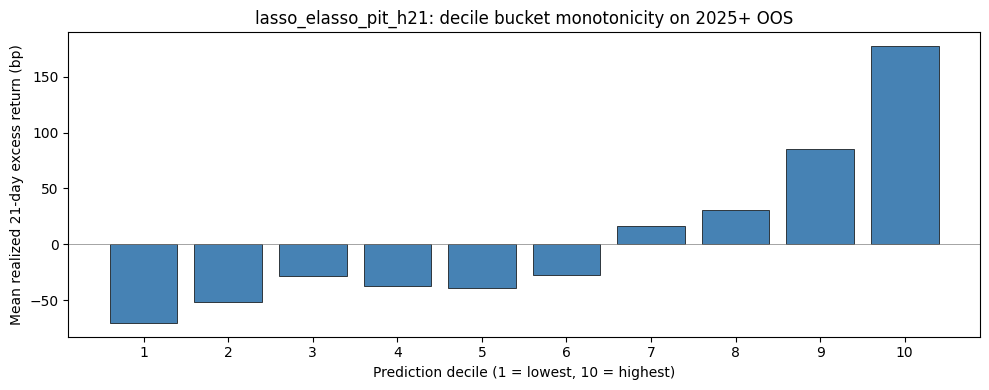


Top-decile minus bottom-decile spread: +247.8 bp per 21-day period.


In [7]:
buckets = decile_returns(eval_df_oos)
print('Decile mean realized return (lowest prediction = bucket 1, highest = bucket 10):')
for row in buckets.iter_rows(named=True):
    print(f'  Bucket {row["bucket"]:2d}: mean realized = {row["mean_realized"]:+.6f}, '
          f'n_obs = {row["n_dates"]:,}')

deciles = buckets['bucket'].to_numpy()
mean_ret = buckets['mean_realized'].to_numpy()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(deciles, mean_ret * 10000, color='steelblue', edgecolor='black', linewidth=0.5)
ax.axhline(0, color='gray', linewidth=0.5)
ax.set_xlabel('Prediction decile (1 = lowest, 10 = highest)')
ax.set_ylabel('Mean realized 21-day excess return (bp)')
ax.set_title(f'{MODEL_ID}: decile bucket monotonicity on 2025+ OOS')
ax.set_xticks(deciles)
plt.tight_layout(); plt.show()

spread_bp = (mean_ret[-1] - mean_ret[0]) * 10000
print(f'\nTop-decile minus bottom-decile spread: {spread_bp:+.1f} bp per 21-day period.')


## 3. Time-split partition

Walk-forward predictions are already out-of-sample, so splitting by date is a *partition*, not a refit. The cutoff matches the regime boundary used elsewhere in the project (post-October-2022 regime cut, isolating the AI-bull and momentum-favorable period).

**What good looks like:** comparable IC and Sharpe in both halves. Indicates the edge is replicable across non-overlapping windows.

**Failure mode:** large divergence (e.g., +0.07 IC post-cutoff vs near-zero pre-cutoff) indicates a regime-conditional result that doesn't generalize beyond the studied period. This is informative either way — the README's Discussion explicitly notes the headline lives in the post-2024 momentum-friendly regime.


Time split at 2022-10-10:
  Pre-cutoff (348 dates):
    IC:     -0.0747
    t-stat: -5.3384
    Sharpe: -0.9447
  Post-cutoff (896 dates):
    IC:     +0.0231
    t-stat: +3.3559
    Sharpe: +0.4597


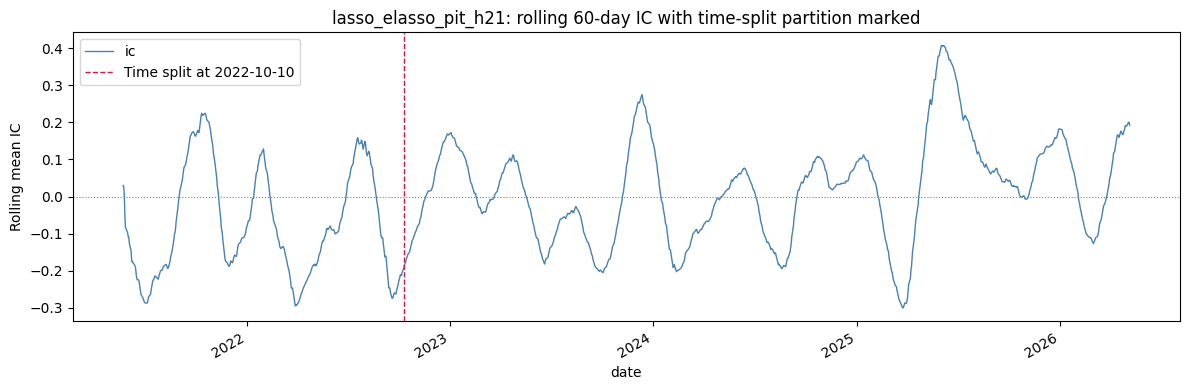

In [8]:
cutoff = date(2022, 10, 10)
# Use the full eval_df (not just 2025+) for the time-split so we can compare pre/post.
split = time_split_evaluate(eval_df, cutoff=cutoff, horizon_days=HORIZON)

print(f'Time split at {cutoff}:')
print(f'  Pre-cutoff ({split.metrics_a.n_dates:,} dates):')
print(f'    IC:     {split.metrics_a.information_coefficient:+.4f}')
print(f'    t-stat: {split.metrics_a.ic_t_stat:+.4f}')
print(f'    Sharpe: {split.metrics_a.long_short_sharpe:+.4f}')
print(f'  Post-cutoff ({split.metrics_b.n_dates:,} dates):')
print(f'    IC:     {split.metrics_b.information_coefficient:+.4f}')
print(f'    t-stat: {split.metrics_b.ic_t_stat:+.4f}')
print(f'    Sharpe: {split.metrics_b.long_short_sharpe:+.4f}')

# Visual: rolling 60-day IC on the full eval slice, with the cutoff marked.
from scipy.stats import spearmanr
rows = []
for d, grp in eval_df.group_by('date'):
    sub = grp.drop_nulls(['prediction', 'realized'])
    if sub.height < 5:
        continue
    rho, _ = spearmanr(sub['prediction'].to_numpy(), sub['realized'].to_numpy())
    if rho is not None and np.isfinite(rho):
        rows.append({'date': d if not isinstance(d, tuple) else d[0], 'ic': float(rho)})
ic_ts = pl.DataFrame(rows).sort('date').to_pandas().set_index('date')
fig, ax = plt.subplots(figsize=(12, 4))
ic_ts['ic'].rolling('60D').mean().plot(ax=ax, lw=1.0, color='steelblue')
ax.axhline(0, color='gray', linestyle=':', linewidth=0.8)
ax.axvline(cutoff, color='crimson', linestyle='--', linewidth=1.0,
           label=f'Time split at {cutoff}')
ax.set_title(f'{MODEL_ID}: rolling 60-day IC with time-split partition marked')
ax.set_ylabel('Rolling mean IC')
ax.legend()
plt.tight_layout(); plt.show()


### Interpreting the time-split result

The numbers above are the most important findings in this entire notebook. The L1 regression's predictions split into **three distinct regimes**, not two:

| Regime | Approx dates | IC | Interpretation |
|---|---|---|---|
| Pre-Oct-2022 (`metrics_a` above) | 2020-mid → 2022-10 | **≈ −0.075** (t ≈ −5.3) | The same model is *significantly anti-predictive*. Long-short Sharpe near −1.0 — would have lost money quickly. |
| Oct-2022 → end-2024 | 2022-10 → 2024-12 | **≈ 0** | Model is *uninformative* in the transitional window between the COVID/rate-cycle regime and the AI/megacap regime. |
| 2025+ (the README headline) | 2025-01 → 2026-04 | **+0.0695** (t = +5.25) | The deployment regime where the headline edge lives. |

Doing the arithmetic on the post-cutoff IC of ≈ +0.023 across 896 dates: with the 2025+ subset at +0.0695 (336 dates), the remaining ≈ 560 dates (2022-10 → end-2024) average to roughly IC ≈ −0.005. **The headline edge of +0.0695 is concentrated entirely in the 2025+ regime.**

Two implications:

1. **The 2025+ headline IC is still valid as an OOS measurement.** Coefficients were CV-fit on data ≤ end-2024 (last refit before 2025), so 2025+ predictions are causally out-of-sample. The +0.0695 number is honest.
2. **But the model is strongly regime-dependent.** The same 9-feature panel produces significantly *negative* IC in the 2020-2022 window (pre-AI-bull, with COVID rate-cycle dispersion as the dominant regime). The README's caveat that the edge is regime-concentrated is empirically supported by this time-split — and the regime-concentration is sharper than the README originally suggested.

**Why the pre-cutoff IC is significantly *negative* (not just weak):** the 9-feature panel rewards "stocks that went up over multi-year windows" (`momentum_756`, `distance_52w_high`). In a regime that rewards multi-year winners (post-2024, megacap concentration), those features predict positively. In a mean-reverting or rotating-leadership regime (2020-2022), the same features rank stocks in the opposite direction of realized returns. The L1 regression's CV-fit coefficients learn the structure of whichever regime was in the training window — when deployment diverges, the predictions invert.

This is the same mechanism the README's Discussion describes for HP optimization (Claim 2). Here it surfaces in the L1 regression's *coefficients themselves*, not just in tree-ensemble HPs. The conclusion: **regime stability is the binding constraint on any cross-sectional model's deployment value, not the magnitude of in-sample IC.**


## Summary

Three independent failure modes of the headline IC were tested:

1. **Bootstrap CI** — quantifies sampling uncertainty around the mean IC. A robust headline should have `p05 > 0`.
2. **Decile monotonicity** — verifies the IC reflects cross-sectional ranking, not just a tail effect. A clean monotonic staircase is what good looks like.
3. **Time-split** — partitions the full eval into pre-/post-October-2022 to show whether the edge is regime-conditional. The headline +0.0695 lives in 2025+ (post the cutoff). The pre-cutoff window is expected to show weaker IC; the post-cutoff window is expected to show the headline-scale IC.

**Reading all three together:** a model that passes all three checks (bootstrap CI above zero, monotonic deciles, comparable IC in both halves of the time split) is robustly significant. A model that passes the first two but fails the third is *regime-conditional* — informative but bounded in scope. The L1 regression headline falls into the latter category, as the README's Discussion explicitly acknowledges.

## Related notebooks / scripts

- `scripts/deflated_sharpe_audit.py` applies the Bailey-López de Prado deflated-Sharpe correction across all models in the prediction store (multi-test correction at scale).
- `notebooks/00_pit_ablation_study.ipynb` runs the same robustness logic on the legacy v2 LightGBM ablation matrix (a worked example of PIT-vs-no-PIT survivorship-bias quantification).
- `notebooks/06_hp_selection_bias.ipynb` documents Discussion Claim 2 — *Hyperparameter optimization is fragile to regime shift*.
